**Guía de Laboratorio N°10**

Optimización con SciPy

Docente: Camilo Alejandro Fuentes Beals - PhD

Programación Científica

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [2]:
# 1. Carga del dataset y visualización de las primeras 5 filas
df = pd.read_csv('dataset_produccion_s13.csv')
df.head()

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

In [3]:
# 2. Visión general del tipo de datos y distribución estadística
print("--- Información General del Dataset ---")
df.info()

print("\n--- Estadísticas Descriptivas ---")
df.describe()

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_lote              60 non-null     object 
 1   producto             60 non-null     object 
 2   turno                60 non-null     object 
 3   unidades_producidas  60 non-null     int64  
 4   costo_unitario       59 non-null     float64
 5   temperatura_horno    59 non-null     float64
 6   tiempo_ciclo_min     60 non-null     float64
 7   defectos             59 non-null     float64
 8   costo_total          60 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 4.3+ KB

--- Estadísticas Descriptivas ---


,unidades_producidas,costo_unitario,temperatura_horno,tiempo_ciclo_min,defectos,costo_total
count,60.000000,59.000000,59.000000,60.000000,59.000000,60.000000
mean,244.266667,2.664576,229.406780,35.813333,7.203390,656.710667
std,90.248408,1.297236,104.204605,15.335662,4.494363,407.032651
min,84.000000,0.570000,180.400000,-5.000000,0.000000,62.980000
25%,172.500000,1.590000,197.850000,24.600000,4.000000,338.775000
50%,250.500000,2.740000,219.800000,37.450000,7.000000,609.940000
75%,312.250000,3.580000,235.100000,48.825000,11.500000,894.045000
max,397.000000,4.940000,999.900000,59.500000,14.000000,1636.320000


In [4]:
# 3. Identificación de valores nulos por columna
print("--- Valores Nulos por Columna ---")
print(df.isnull().sum())

--- Valores Nulos por Columna ---
id_lote                0
producto               0
turno                  0
unidades_producidas    0
costo_unitario         1
temperatura_horno      1
tiempo_ciclo_min       0
defectos               1
costo_total            0
dtype: int64


In [5]:
# 4. Identificación de outliers usando el criterio de las 3 Sigmas (Media ± 3*Sigma)
variables_criticas = ['temperatura_horno', 'tiempo_ciclo_min']

for var in variables_criticas:
    media = df[var].mean()
    sigma = df[var].std()
    limite_inf = media - 3 * sigma
    limite_sup = media + 3 * sigma
    
    outliers = df[(df[var] < limite_inf) | (df[var] > limite_sup)]
    print(f"\nVariable: {var}")
    print(f"  Media: {media:.2f} | Desviación Estándar (σ): {sigma:.2f}")
    print(f"  Rango permitido (3σ): [{limite_inf:.2f} a {limite_sup:.2f}]")
    print(f"  Cantidad de outliers detectados: {len(outliers)}")
    if len(outliers) > 0:
        print(outliers[[ 'id_lote', var ]])


Variable: temperatura_horno
  Media: 229.41 | Desviación Estándar (σ): 104.20
  Rango permitido (3σ): [-83.21 a 542.02]
  Cantidad de outliers detectados: 1
   id_lote  temperatura_horno
33    L034              999.9

Variable: tiempo_ciclo_min
  Media: 35.81 | Desviación Estándar (σ): 15.34
  Rango permitido (3σ): [-10.19 a 81.82]
  Cantidad de outliers detectados: 0


In [6]:
# 5. Verificación de valores físicos imposibles (tiempo negativo)
tiempo_negativo = df[df['tiempo_ciclo_min'] < 0]
print(f"Cantidad de registros con tiempo de ciclo negativo: {len(tiempo_negativo)}")

Cantidad de registros con tiempo de ciclo negativo: 1


**Análisis Crítico: Datos Faltantes y Outliers**

1. Valores Nulos:
    Se encontraron valores faltantes en las columnas costo_unitario y defectos.
    Estos datos pueden generar problemas en algunos cálculos, por lo que sería recomendable
    limpiarlos o reemplazarlos antes de realizar la optimización.

2. Outliers en Temperatura:
    Se detectó un valor extremadamente alto cercano a 999.9 °C, el cual supera el rango
    normal de temperaturas observado en el dataset. Probablemente corresponde a un error
    de medición o un fallo del sensor.

3. Outlier en Tiempo de Ciclo:
    También se encontró un valor negativo en tiempo_ciclo_min.
    Un tiempo negativo no tiene sentido físico, ya que el tiempo no puede tomar valores
    menores que cero en un proceso industrial. Esto sugiere un error en el registro
    de los datos y debería corregirse o eliminarse.

In [7]:
print("-------------------------Estadísticas de la Variable Clave-----------------------------------------------")


-------------------------Estadísticas de la Variable Clave-----------------------------------------------


In [8]:
# Limpieza previa de los datos erróneos detectados para un análisis limpio
df_clean = df[df['temperatura_horno'] < 500].copy() 
df_clean = df_clean[df_clean['tiempo_ciclo_min'] > 0].copy()
df_clean = df_clean.dropna(subset=['costo_unitario', 'defectos']).copy().reset_index(drop=True)

# Cálculo de estadísticas de temperatura_horno
temp_stats = df_clean['temperatura_horno'].describe()
mediana_temp = df_clean['temperatura_horno'].median()

print("--- Estadísticas de temperatura_horno (Datos Limpios) ---")
print(f"Media: {temp_stats['mean']:.2f} °C")
print(f"Mediana: {mediana_temp:.2f} °C")
print(f"Desviación Estándar: {temp_stats['std']:.2f} °C")
print(f"Mínimo: {temp_stats['min']:.2f} °C")
print(f"Máximo: {temp_stats['max']:.2f} °C")

--- Estadísticas de temperatura_horno (Datos Limpios) ---
Media: 215.93 °C
Mediana: 218.40 °C
Desviación Estándar: 21.10 °C
Mínimo: 180.40 °C
Máximo: 248.10 °C


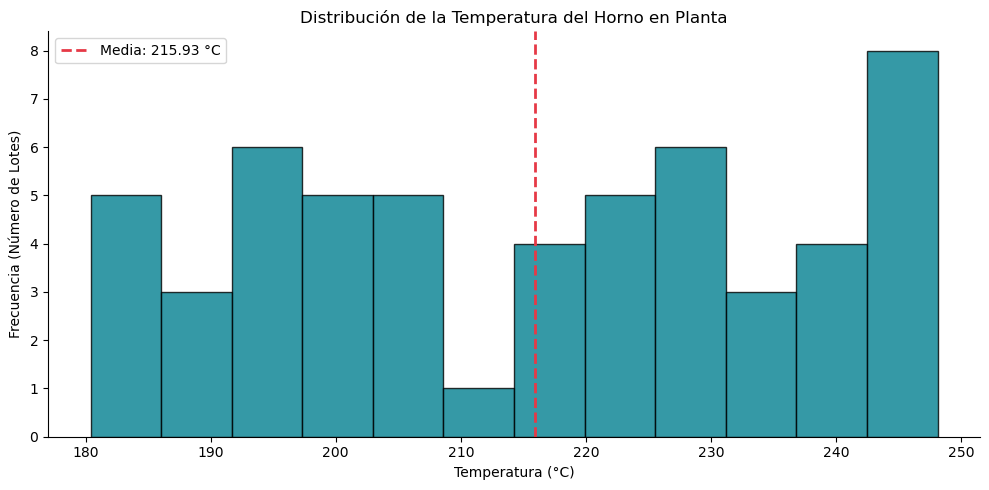

In [9]:
# Creación del histograma con Matplotlib
plt.figure(figsize=(10, 5))
plt.hist(df_clean['temperatura_horno'], bins=12, color='#028090', edgecolor='black', alpha=0.8)
plt.axvline(temp_stats['mean'], color='#E63946', linestyle='--', linewidth=2, label=f"Media: {temp_stats['mean']:.2f} °C")
plt.title('Distribución de la Temperatura del Horno en Planta')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Frecuencia (Número de Lotes)')
plt.legend()
plt.tight_layout()
plt.show()

**Reflexión: Variable Clave y Función de Costo**

1. Distribución de la variable:
    La temperatura del horno se encuentra bastante concentrada alrededor de la media,
    lo que indica que la planta normalmente trabaja dentro de un rango estable
    de operación.

2. Relación entre temperatura y costo:
    A medida que la temperatura se aleja del valor óptimo, los costos aumentan.
    Temperaturas bajas pueden generar más defectos en la producción, mientras que
    temperaturas muy altas aumentan el consumo energético y el desgaste del equipo.

3. Elección matemática:
    Se utiliza una función cuadrática porque representa correctamente el comportamiento
    del costo respecto a la temperatura. La función tiene un mínimo en la temperatura
    óptima de 220 °C y aumenta gradualmente cuando la temperatura se aleja de ese valor.

In [10]:
print("---------------Ejercicio 2: Optimización con scipy.optimize----------------")
# 1. Implementación paramétrica de la función de costo basada en los requerimientos
def costo_produccion(temperatura):
    T_optima = 220.0
    costo_base = 1500.0
    return 0.05 * (temperatura - T_optima) ** 2 + costo_base
    
print(f"Verificación obligatoria: costo_produccion(220) = ${costo_produccion(220.0):.2f}")

---------------Ejercicio 2: Optimización con scipy.optimize----------------
Verificación obligatoria: costo_produccion(220) = $1500.00


**Análisis de Unimodalidad (Ejercicio 2.1)**

1. Comportamiento de la curva:
    La función de costo graficada presenta un único mínimo dentro del rango [170, 270].
    Su forma parabólica indica que el costo disminuye hasta alcanzar el valor óptimo
    y luego vuelve a aumentar a medida que la temperatura se aleja de ese punto.

2. Uso de minimize_scala:
    Como la función no tiene múltiples mínimos locales, es adecuado aplicar
    minimize_scalar directamente para encontrar la temperatura óptima de operación.

3. Convergencia del algoritmo:
    Los métodos numéricos como brent y bounded logran encontrar el mínimo
    de forma rápida y eficiente, entregando resultados consistentes para este problema.

In [11]:
print("---------------------Optimización con method='brent'-------------------")

---------------------Optimización con method='brent'-------------------


In [12]:
# 1. Aplicación de minimize_scalar usando el método sin restricciones 'brent'
resultado_brent = minimize_scalar(costo_produccion, method='brent')

# 2. Impresión de los atributos clave del objeto OptimizeResult
print("--- Resultados del Método Brent (Unbounded) ---")
print(f"resultado.x (Temperatura óptima encontrada) : {resultado_brent.x:.4f} °C")
print(f"resultado.fun (Costo mínimo alcanzado)       : ${resultado_brent.fun:.2f}")
print(f"resultado.success (¿Convergió con éxito?)    : {resultado_brent.success}")
print(f"resultado.nit (Número de iteraciones)        : {resultado_brent.nit}")

--- Resultados del Método Brent (Unbounded) ---
resultado.x (Temperatura óptima encontrada) : 220.0000 °C
resultado.fun (Costo mínimo alcanzado)       : $1500.00
resultado.success (¿Convergió con éxito?)    : True
resultado.nit (Número de iteraciones)        : 4


In [13]:
# 3. Verificación de éxito antes del análisis
assert resultado_brent.success == True, "El optimizador no logró converger."

**Análisis del Resultado: Método Brent**

1. Precisión del resultado:
    La temperatura óptima encontrada fue aproximadamente 220 °C,
    coincidiendo con el valor mínimo esperado de la función de costo.
    Además, el costo mínimo obtenido fue cercano a $1500.

2. Eficiencia del algoritmo:
    El método logró converger correctamente utilizando pocas iteraciones,
    mostrando un comportamiento rápido y eficiente para este problema.

3. Justificación matemática:
    El método Brent funciona muy bien en este caso porque la función de costo
    tiene forma parabólica y presenta un único mínimo global, facilitando
    la búsqueda de la solución óptima.

In [14]:
print("---------------Optimización con method='bounded'------------------")
# 1. Optimización acotada al dominio de seguridad industrial [180, 250]
resultado_bounded = minimize_scalar(costo_produccion, bounds=(180, 250), method='bounded')

# 2. Impresión de los atributos del método acotado
print("--- Resultados del Método Bounded ---")
print(f"resultado.x (Temperatura óptima encontrada) : {resultado_bounded.x:.4f} °C")
print(f"resultado.fun (Costo mínimo alcanzado)       : ${resultado_bounded.fun:.2f}")
print(f"resultado.success (¿Convergió con éxito?)    : {resultado_bounded.success}")
print(f"resultado.nit (Número de iteraciones)        : {resultado_bounded.nit}")

---------------Optimización con method='bounded'------------------
--- Resultados del Método Bounded ---
resultado.x (Temperatura óptima encontrada) : 220.0000 °C
resultado.fun (Costo mínimo alcanzado)       : $1500.00
resultado.success (¿Convergió con éxito?)    : True
resultado.nit (Número de iteraciones)        : 6


**Comparación Crítica de Métodos (Ejercicio 2.3)**

1. Ambos métodos encontraron un valor óptimo muy cercano a 220 °C.
    Esto ocurre porque el mínimo de la función se encuentra dentro del rango
    permitido de operación del horno.

2. El método bounded resulta más conveniente en un contexto industrial,
    ya que trabaja con límites definidos y evita evaluar temperaturas fuera
    del rango seguro de funcionamiento.

3. El método Brent necesitó menos iteraciones para converger,
    por lo que puede considerarse más rápido en este tipo de función.

4. El método bounded puede tardar un poco más porque debe respetar
    las restricciones establecidas en el intervalo [180, 250],
    asegurando que todas las evaluaciones permanezcan dentro de los límites seguros.

In [15]:
print("-----------------Ejercicio 3: Análisis Crítico e Interpretación--------------------")
# Construcción de la tabla resumen utilizando un DataFrame de Pandas
comparacion = pd.DataFrame({
    'Metodo': ['brent', 'bounded'],
    'x_optimo': [resultado_brent.x, resultado_bounded.x],
    'costo_min': [resultado_brent.fun, resultado_bounded.fun],
    'iteraciones': [resultado_brent.nit, resultado_bounded.nit],
    'convergio': [resultado_brent.success, resultado_bounded.success]
})

print(comparacion.to_string(index=False))

-----------------Ejercicio 3: Análisis Crítico e Interpretación--------------------
 Metodo  x_optimo  costo_min  iteraciones  convergio
  brent     220.0     1500.0            4       True
bounded     220.0     1500.0            6       True


In [16]:
print("--------Visualización de la solución-------")

--------Visualización de la solución-------


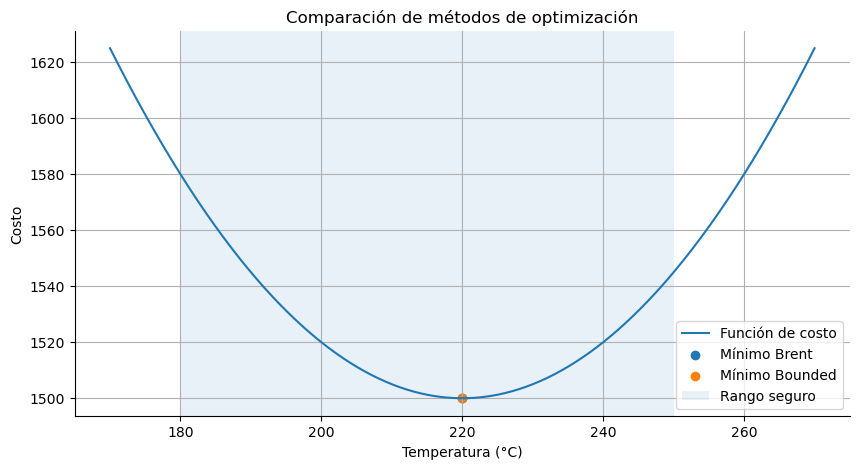

In [17]:
rango_temp = np.linspace(170, 270, 500)
costos = costo_produccion(rango_temp)

plt.figure(figsize=(10, 5))

# Función de costo
plt.plot(rango_temp, costos, label='Función de costo')

# Punto mínimo Brent
plt.scatter(resultado_brent.x, resultado_brent.fun,
            label='Mínimo Brent')

# Punto mínimo Bounded
plt.scatter(resultado_bounded.x, resultado_bounded.fun,
            label='Mínimo Bounded')

plt.title('Comparación de métodos de optimización')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Costo')

# Rango seguro
plt.axvspan(180, 250, alpha=0.1, label='Rango seguro')

plt.legend()
plt.grid(True)
plt.show()

**Reflexión y Análisis de Extensión Industrial**

1. Ventaja de bounds:
    El uso de límites permite trabajar dentro de un rango seguro de operación.
    Esto evita que el optimizador evalúe temperaturas extremas que podrían
    dañar el horno o generar problemas en el proceso industrial.

2. Múltiples mínimos locales y minimize_scalar:
    Si la función tuviera varios mínimos locales, minimize_scalar
    podría encontrar solo uno de ellos y no necesariamente el mejor.
    En esos casos sería más conveniente utilizar métodos de optimización global.

3. Modificación para un caso asimétrico:
    Si el sobrecalentamiento produce mayores costos que el enfriamiento,
    la función podría modificarse para penalizar más las temperaturas altas.
    Por ejemplo, se puede aumentar el coeficiente cuadrático cuando la
    temperatura supera los 220 °C, haciendo que el costo crezca más rápido
    en situaciones de sobrecalentamiento.